In [2]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys

warnings.filterwarnings("ignore")
sys.path.append('../src-double-gyre')
sys.path.append('../src')
from plot_helpers import create_animation_ffmpeg

%load_ext autoreload
%autoreload 3

# Goal
Create calibration dataset for NW2 configuration

In [2]:
data = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R32/R2_FGR3/topography_corrected.nc', decode_times=False)
static = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/static.nc', decode_times=False).drop_vars('time')

In [3]:
from xgcm import Grid
grid = Grid(static, coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'}
        },
        boundary={'X': 'periodic', 'Y': 'fill'},
        fill_value = {'Y': 0})

# Energetics

In [4]:
from dask.diagnostics import ProgressBar
rho0 = 1000.
scaling = 1.e-15
with ProgressBar():
    KE = scaling * 0.5 * ((grid.interp(data.u**2, 'X') + grid.interp(data.v**2, 'Y')) * data.h * static.area_t * rho0).sum(['xh','yh']).compute()

[########################################] | 100% Completed | 1.92 sms


In [ ]:
interface_rest = xr.DataArray([    0.,   -25.,   -75.,  -175.,  -300.,  -450.,  -625.,  -825.,
       -1050., -1300., -1600., -1950., -2350., -2850., -3400., -4000.], dims='zi')

g = xr.DataArray([1.0e+01, 2.1e-03, 3.9e-03, 5.4e-03, 5.8e-03, 5.8e-03, 5.7e-03,
   5.3e-03, 4.8e-03, 4.2e-03, 3.7e-03, 3.1e-03, 2.4e-03, 1.7e-03,
   1.1e-03, 0.0e+00], dims='zi')

area_t = static.area_t
coordinate_of_bottom = - static.depth_ocean

hint = data.e - interface_rest
hbot = np.maximum(coordinate_of_bottom - interface_rest,0)

APE_instant = (0.5 * rho0 * g * (hint**2) * area_t)
APE_constant = (0.5 * rho0 * g * (hbot**2) * area_t)

with ProgressBar():
    APE = scaling * (APE_instant - APE_constant).sum(['xh', 'yh']).compute()

[###############################         ] | 77% Completed | 1.31 s ms

In [6]:
dataset = xr.Dataset()
dataset['KE_mean'] = KE.mean('time')
dataset['APE_mean'] = APE.mean('time')

dataset['KE_std'] = KE.std('time')
dataset['APE_std'] = APE.std('time')

In [7]:
print(KE.sum('zl')[0].item() / scaling)
print(APE.sum('zi')[0].item() / scaling)

1.3339231289727857e+18
9.551214050809541e+19


In [8]:
print(KE[-1][0].item() / scaling)
print(APE[-2][0].item() / scaling)

4.6006815584001384e+16
2.848135051840386e+17


In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
KE.sum('zl').plot()
plt.axhline(y=dataset['KE_mean'].sum('zl'), color='k')
plt.subplot(1,2,2)
APE.sum('zi').plot()
plt.axhline(y=dataset['APE_mean'].sum('zi'), color='k')

# Interfaces

In [9]:
dataset['e_mean'] = data.e.mean('time').compute().fillna(0.)
dataset['e_std'] = data.e.std('time').compute().fillna(0.)

In [10]:
mask = dataset['e_mean'] > - static.depth_ocean.fillna(0.) + 10

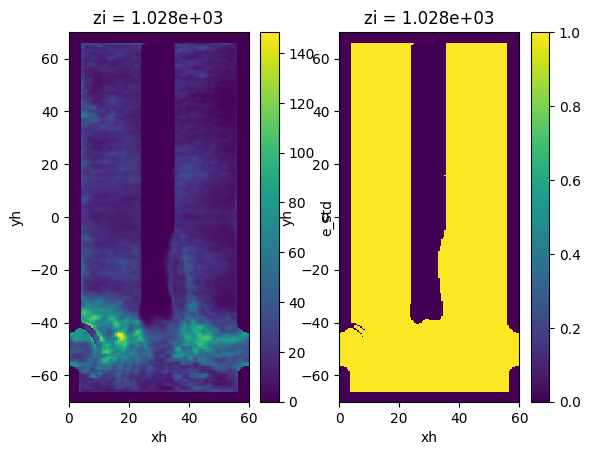

In [11]:
zi = 12
plt.subplot(1,2,1)
dataset['e_std'][zi].plot()
plt.subplot(1,2,2)
mask[zi].plot()

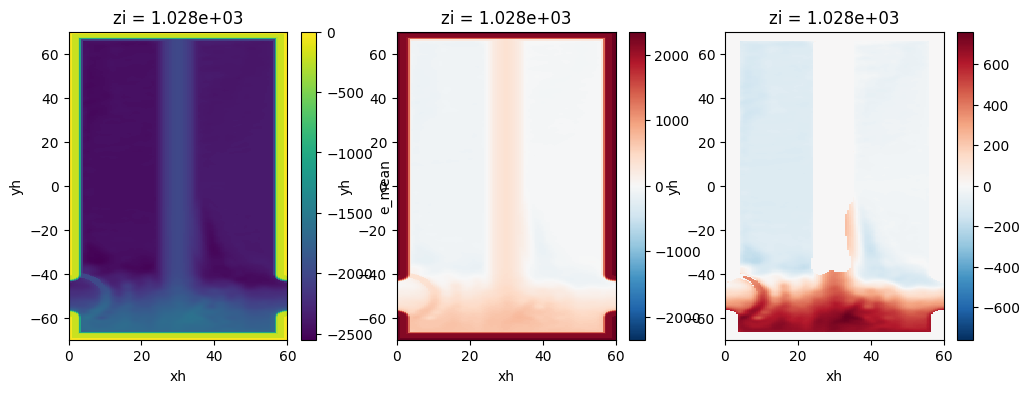

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
dataset['e_mean'][zi].plot()
plt.subplot(1,3,2)
(dataset['e_mean'] - interface_rest)[zi].plot()
plt.subplot(1,3,3)
(mask*(dataset['e_mean'] - interface_rest))[zi].plot()

# Normalization constants

In [13]:
dataset

<xarray.Dataset> Size: 4MB
Dimensions:   (zl: 15, zi: 16, yh: 280, xh: 120)
Coordinates:
  * zl        (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03 1.028e+03
  * zi        (zi) float64 128B 1.022e+03 1.023e+03 1.023e+03 ... 1.028e+03 nan
  * yh        (yh) float64 2kB -69.75 -69.25 -68.75 -68.25 ... 68.75 69.25 69.75
  * xh        (xh) float64 960B 0.25 0.75 1.25 1.75 ... 58.25 58.75 59.25 59.75
Data variables:
    KE_mean   (zl) float64 120B 43.56 66.74 130.4 98.44 ... 52.32 46.78 37.67
    APE_mean  (zi) float64 128B 402.8 186.2 1.503e+03 4e+03 ... 473.0 286.5 0.0
    KE_std    (zl) float64 120B 3.525 3.44 5.002 3.349 ... 2.185 2.43 2.054
    APE_std   (zi) float64 128B 5.439 1.087 9.88 19.85 ... 16.37 7.104 3.135 0.0
    e_mean    (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    e_std     (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

# Not noise-based normalization constants

In [14]:
# The resulting loss for the energetics is
# (KE-KE_true)**2/KE_true**2
# layerwise
for variable in ['KE_mean', 'KE_std', 'APE_mean', 'APE_std']:
    dataset[f'{variable}_var_loss'] = dataset[variable]**2

In [15]:
dataset['e_std_var_loss'] = (dataset.e_std**2).sum(['xh', 'yh']) + 0 * dataset['e_std']
e_mean_corrected = mask*(dataset['e_mean'] - interface_rest)
dataset['e_mean_var_loss'] = (e_mean_corrected**2).sum(['xh', 'yh']) + 0 * dataset['e_mean']

In [16]:
dataset = dataset.isel(zi=slice(0,-1)).transpose('zl',...).transpose('zi',...)

In [17]:
dataset

<xarray.Dataset> Size: 10MB
Dimensions:            (zl: 15, zi: 15, yh: 280, xh: 120)
Coordinates:
  * zl                 (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * zi                 (zi) float64 120B 1.022e+03 1.023e+03 ... 1.028e+03
  * yh                 (yh) float64 2kB -69.75 -69.25 -68.75 ... 69.25 69.75
  * xh                 (xh) float64 960B 0.25 0.75 1.25 ... 58.75 59.25 59.75
Data variables:
    KE_mean            (zl) float64 120B 43.56 66.74 130.4 ... 52.32 46.78 37.67
    APE_mean           (zi) float64 120B 402.8 186.2 1.503e+03 ... 473.0 286.5
    KE_std             (zl) float64 120B 3.525 3.44 5.002 ... 2.185 2.43 2.054
    APE_std            (zi) float64 120B 5.439 1.087 9.88 ... 16.37 7.104 3.135
    e_mean             (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    e_std              (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    KE_mean_var_loss   (zl) float64 120B 1.897e+03 4.454e+03 ... 1.419e+03
    KE_std_var_loss    (zl) float64 120B 12.42 11.84 25.02 ... 4.772 5.907 4.22
    APE_mean_var_loss  (zi) float64 120B 1.623e+05 3.468e+04 ... 8.207e+04
    APE_std_var_loss   (zi) float64 120B 29.59 1.182 97.61 ... 268.1 50.47 9.829
    e_std_var_loss     (zi, yh, xh) float32 2MB 566.6 566.6 ... 1.155e+07
    e_mean_var_loss    (zi, yh, xh) float64 4MB dask.array<chunksize=(15, 280, 120), meta=np.ndarray>

In [33]:
dataset.astype('float32').fillna(0.).to_netcdf('../scripts/R32_R2_FGR3_NW2/800days.nc')

# Additional normalization constants
We introduce simple normalization where each degree of freedom is normalized such that unparameterized simulation has weighted squared error equal 1. That way we will clearly see which degrees of freedom we were able to improve.

In [18]:
dataset = xr.open_dataset('../scripts/R32_R2_FGR3_NW2/800days.nc')

In [19]:
control = xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/snapshots_00001005.nc', decode_times=False
                         ).isel(time=slice(0,160)).isel(zi=slice(0,-1))

In [20]:
control_metrics = xr.Dataset()

In [21]:
control_metrics['e_mean'] = control.e.mean('time')
control_metrics['e_std'] = control.e.std('time')

In [22]:
series = 1.e-15 * xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/ocean.stats.nc', decode_times=False).sel(Time=slice(1000.,1800)).rename({'Layer': 'zl', 'Interface': 'zi'}).isel(zi=slice(0,-1))

In [23]:
control_metrics['KE_mean'] = series.KE.mean('Time')
control_metrics['APE_mean'] = series.APE.mean('Time')
control_metrics['KE_std'] = series.KE.std('Time')
control_metrics['APE_std'] = series.APE.std('Time')

In [24]:
dataset['e_std_var_ctrl'] = ((dataset.e_std - control_metrics['e_std'])**2).sum(['xh', 'yh']) + 0 * dataset['e_std']
dataset['e_mean_var_ctrl'] = ((dataset.e_mean - control_metrics['e_mean'])**2).sum(['xh', 'yh']) + 0 * dataset['e_mean']

In [25]:
# The resulting loss for the energetics is
# (KE-KE_true)**2/[(KE_control-KE_true)**2 + KE_control_std**2 + KE_true_std**2)
#We use a measure of standard deviation to prevent division by zero
# layerwise
dataset['KE_mean_var_ctrl'] = (dataset['KE_mean'] - control_metrics['KE_mean'])**2

# ill-conditioned APE
We have problem with ill-conditioned APE structure. Where we have the largest amount of APE (6th layer), there we have the smallest error of unparameterized model. This results in a very big weighting of error in this layer, although the contribution from this layer to total APE is clearly not decisive. Thus, we aggregate the APE normalization constant over the layers. Because we want to have an output which sum up to 15, we do mean but not sum

In [26]:
dataset['APE_mean_var_ctrl'] = ((dataset['APE_mean'] - control_metrics['APE_mean'])**2).mean('zi') + 0* dataset['APE_mean']

In [107]:
dataset.astype('float32').fillna(0.).to_netcdf('../scripts/R32_R2_FGR3_NW2/800days_v1.nc')

# Check the loss function based on the reduced gravities

In [131]:
dataset  = xr.open_dataset('../scripts/R32_R2_FGR3_NW2/800days_v1.nc').load()

In [2]:
data = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R32/R2_FGR3/topography_corrected.nc', decode_times=False)
static = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/static.nc', decode_times=False).drop_vars('time')

In [3]:
stats = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/ocean.stats.nc', decode_times=False)

In [4]:
from xgcm import Grid
grid = Grid(static, coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'}
        },
        boundary={'X': 'periodic', 'Y': 'fill'},
        fill_value = {'Y': 0})

In [5]:
g = xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-long/bare/output/Vertical_coordinate.nc').g.rename({'Layer': 'zi'}).compute().drop_vars(['zi'])

In [11]:
g_ratio = g[0] / g

In [12]:
dataset['g_ratio'] = g_ratio

In [137]:
interfaces = data.e.isel(zi=slice(0,-1)).fillna(0.)

In [139]:
x = ((interfaces - interfaces.mean('time'))**3).mean('time')
dataset['e_3rd'] = (np.sign(x) * np.abs(x)**(1./3.)).compute()

In [140]:
dataset['e_4th'] = ((((interfaces - interfaces.mean('time'))**4).mean('time'))**(1./4.)).compute()

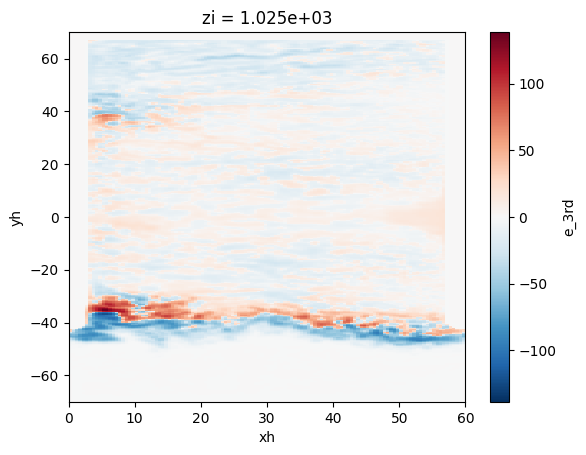

In [141]:
dataset['e_3rd'][5].plot()

In [142]:
dataset['e_mean_var_gratio'] = g_ratio**2 + 0*dataset['e_mean']
dataset['e_std_var_gratio']  = g_ratio**2 + 0*dataset['e_std']
dataset['e_3rd_var_gratio']  = g_ratio**2 + 0*dataset['e_3rd']
dataset['e_4th_var_gratio']  = g_ratio**2 + 0*dataset['e_4th']

In [143]:
dataset

<xarray.Dataset> Size: 32MB
Dimensions:            (zl: 15, zi: 15, yh: 280, xh: 120)
Coordinates:
  * zl                 (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * zi                 (zi) float64 120B 1.022e+03 1.023e+03 ... 1.028e+03
  * yh                 (yh) float64 2kB -69.75 -69.25 -68.75 ... 69.25 69.75
  * xh                 (xh) float64 960B 0.25 0.75 1.25 ... 58.75 59.25 59.75
Data variables: (12/22)
    KE_mean            (zl) float32 60B 43.56 66.74 130.4 ... 52.32 46.78 37.67
    APE_mean           (zi) float32 60B 402.8 186.2 1.503e+03 ... 473.0 286.5
    KE_std             (zl) float32 60B 3.525 3.44 5.002 ... 2.185 2.43 2.054
    APE_std            (zi) float32 60B 5.439 1.087 9.88 ... 16.37 7.104 3.135
    e_mean             (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    e_std              (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                 ...
    e_3rd              (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    e_4th              (zi, yh, xh) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    e_mean_var_gratio  (zi, yh, xh) float64 4MB 1.0 1.0 ... 8.264e+07 8.264e+07
    e_std_var_gratio   (zi, yh, xh) float64 4MB 1.0 1.0 ... 8.264e+07 8.264e+07
    e_3rd_var_gratio   (zi, yh, xh) float64 4MB 1.0 1.0 ... 8.264e+07 8.264e+07
    e_4th_var_gratio   (zi, yh, xh) float64 4MB 1.0 1.0 ... 8.264e+07 8.264e+07

In [144]:
dataset.astype('float32').fillna(0.).to_netcdf('../scripts/R32_R2_FGR3_NW2/800days_v2.nc')

In [ ]:
data

# Adding PCA spectrum

In [6]:
dataset = xr.open_dataset('../scripts/R32_R2_FGR3_NW2/800days_v2.nc')

In [13]:
dataset['g_ratio'] = g_ratio

In [14]:
interfaces = data.e.isel(zi=slice(0,-1)).fillna(0.)

In [15]:
interfaces_scaled = ((interfaces - interfaces.mean('time')) / dataset.g_ratio).compute()

In [16]:
Nt = interfaces_scaled.shape[0]
X_true = interfaces_scaled.values.reshape(Nt,-1)

In [17]:
svd_true = np.linalg.svd(X_true, full_matrices=False)

In [18]:
dataset['PCA_Vh'] = xr.DataArray(svd_true.Vh, dims=['PCA', 'NzNyNx'])

In [19]:
dataset['PCA_S2_over_Nt'] = xr.DataArray(svd_true.S**2 / Nt, dims='PCA')

In [20]:
dataset['cov_fro_distance_10'] = 0.
dataset['cov_fro_distance_10_var'] = 1.

In [21]:
dataset.astype('float32').fillna(0.).to_netcdf('../scripts/R32_R2_FGR3_NW2/800days_v3.nc')

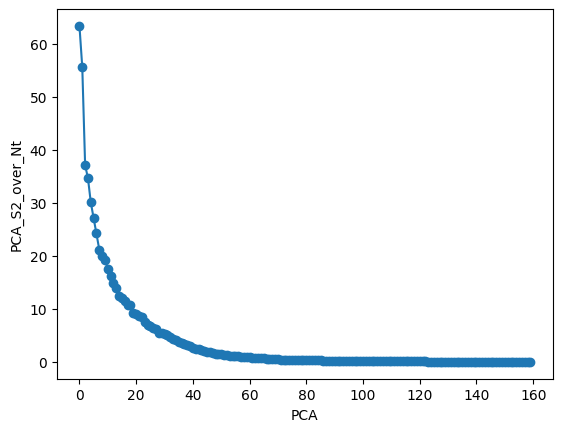

In [26]:
dataset['PCA_S2_over_Nt'].plot(marker='o')

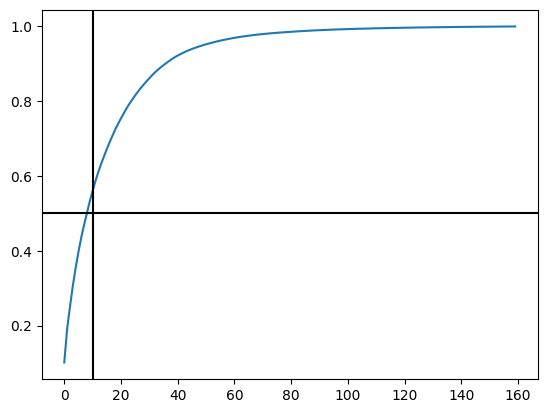

In [31]:
plt.plot(np.cumsum(dataset['PCA_S2_over_Nt']) / np.sum(dataset['PCA_S2_over_Nt']))
plt.axhline(y=0.5,color='k')
plt.axvline(x=10,color='k')

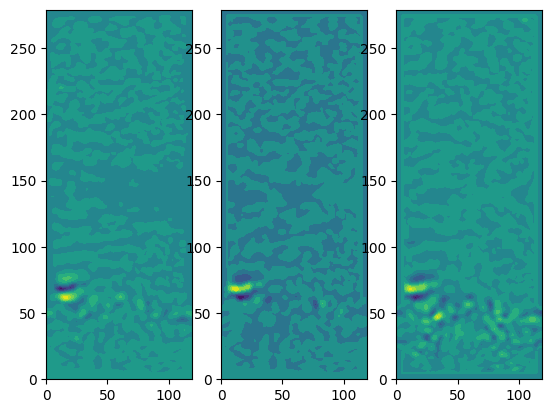

In [40]:
plt.subplot(1,3,1)
plt.contourf(dataset['PCA_Vh'][0].values.reshape(15,280,120)[0], levels=10)
plt.subplot(1,3,2)
plt.contourf(dataset['PCA_Vh'][0].values.reshape(15,280,120)[5], levels=10)
plt.subplot(1,3,3)
plt.contourf(dataset['PCA_Vh'][0].values.reshape(15,280,120)[10], levels=10)

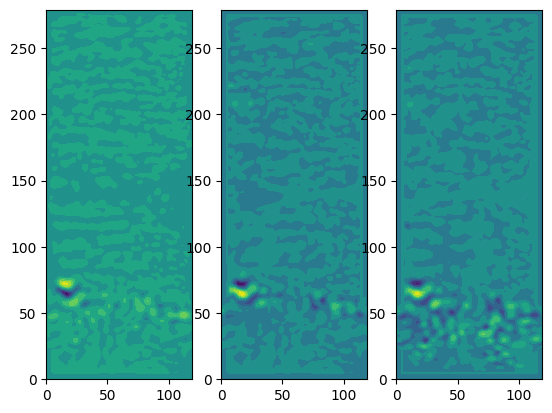

In [41]:
plt.subplot(1,3,1)
plt.contourf(dataset['PCA_Vh'][1].values.reshape(15,280,120)[0], levels=10)
plt.subplot(1,3,2)
plt.contourf(dataset['PCA_Vh'][1].values.reshape(15,280,120)[5], levels=10)
plt.subplot(1,3,3)
plt.contourf(dataset['PCA_Vh'][1].values.reshape(15,280,120)[10], levels=10)

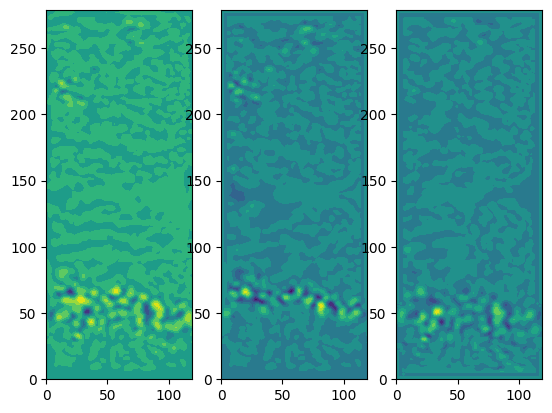

In [42]:
plt.subplot(1,3,1)
plt.contourf(dataset['PCA_Vh'][5].values.reshape(15,280,120)[0], levels=10)
plt.subplot(1,3,2)
plt.contourf(dataset['PCA_Vh'][5].values.reshape(15,280,120)[5], levels=10)
plt.subplot(1,3,3)
plt.contourf(dataset['PCA_Vh'][5].values.reshape(15,280,120)[10], levels=10)

# Add new normalization which treats all layers equally

In [8]:
dataset = xr.open_dataset('../scripts/R32_R2_FGR3_NW2/800days_v3.nc')

In [9]:
number_of_subsurface_layers = 14
dataset['e_mean_var_gratio_n'] = dataset['e_mean_var_gratio']
dataset['e_mean_var_gratio_n'][1:] = dataset['e_mean_var_gratio_n'][1:] / number_of_subsurface_layers**2
dataset['e_std_var_gratio_n'] = dataset['e_mean_var_gratio_n']
dataset['e_3rd_var_gratio_n'] = dataset['e_mean_var_gratio_n']
dataset['e_4th_var_gratio_n'] = dataset['e_mean_var_gratio_n']

In [10]:
dataset.to_netcdf('../scripts/R32_R2_FGR3_NW2/800days_v4.nc')

# Check normalization as zero Montgomery at the bottom

In [34]:
dataset = xr.open_dataset('../scripts/R32_R2_FGR3_NW2/800days_v4.nc')

In [36]:
np.sqrt(np.unique(dataset.e_mean_var_gratio_n))

array([  1.     , 123.1527 , 125.31328, 132.27513, 134.77089, 148.80952,
       170.06802, 183.15018, 193.0502 , 230.41475, 297.61905, 340.13605,
       420.16806, 649.35065], dtype=float32)

Text(0.5, 1.0, 'Surface STD of interfaces')

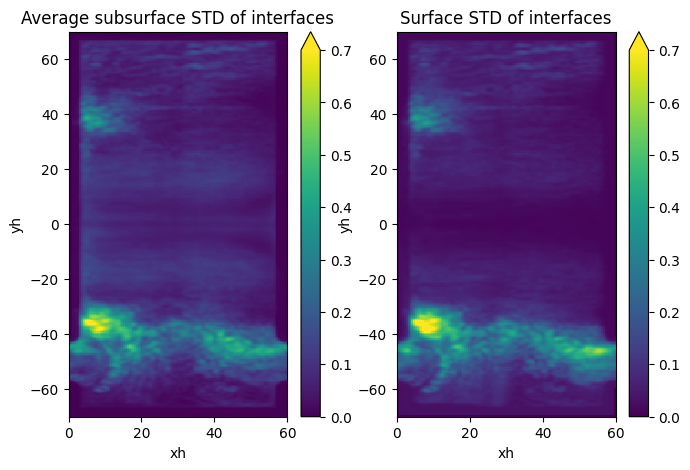

In [29]:
plt.figure(figsize=(12,5))
e_std = dataset.e_std/np.sqrt(dataset.e_std_var_gratio_n)
plt.subplot(1,3,1)
(e_std.isel(zi=slice(1,-1)).mean('zi')).plot(vmin=0., vmax=0.7)
plt.title('Average subsurface STD of interfaces')

plt.subplot(1,3,2)
(e_std).isel(zi=0).plot(vmin=0., vmax=0.7)
plt.title('Surface STD of interfaces')

# plt.subplot(1,3,3)
# plt.scatter((e_std).isel(zi=0), (e_std.isel(zi=slice(1,-1))).sum('zi'))
# plt.plot([0, 1], [0, 1], 'k--')

In [30]:
e_scaled = dataset.e_mean  / np.sqrt(dataset.e_mean_var_gratio_n)

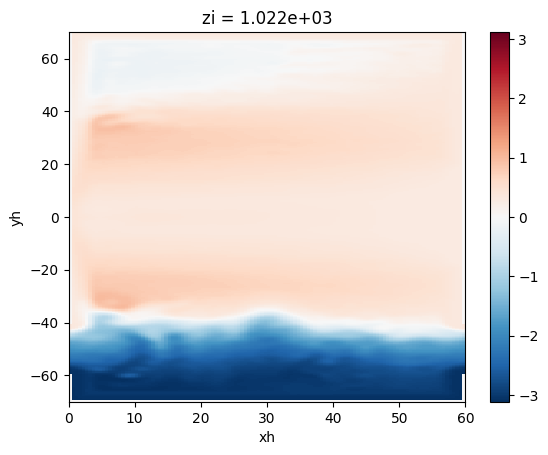

In [31]:
e_scaled.isel(zi=0).plot()

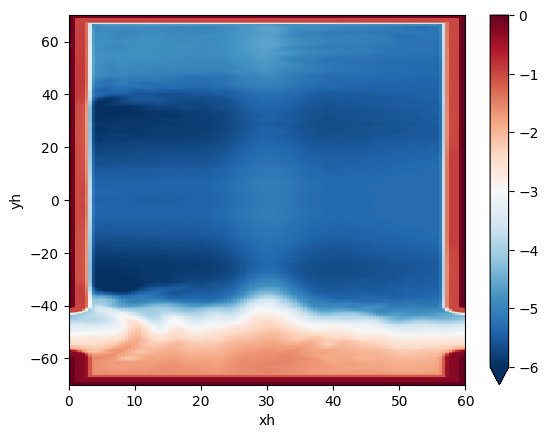

In [33]:
# Approximately zero pressure gradient at the bottom
e_scaled.isel(zi=slice(1,-1)).mean('zi').plot(vmin=-6,vmax=0, cmap='RdBu_r')

# Why the loss function is dominated by the surface? 

In [57]:
e_std_scaled = dataset.e_std / np.sqrt(dataset.e_std_var_gratio)

In [62]:
e_std_horizontal_l2_norm = np.sqrt((e_std_scaled**2).mean(['xh', 'yh']))
e_std_horizontal_l2_norm = e_std_horizontal_l2_norm / e_std_horizontal_l2_norm[0] # Just for convenience

In [63]:
e_std_horizontal_l2_norm

<xarray.DataArray (zi: 15)> Size: 60B
array([1.        , 0.01574961, 0.04803026, 0.08346458, 0.09353853,
       0.10702166, 0.12573758, 0.12817404, 0.11945583, 0.10079107,
       0.08381161, 0.06751403, 0.04949216, 0.03012691, 0.0157064 ],
      dtype=float32)
Coordinates:
  * zi       (zi) float64 120B 1.022e+03 1.023e+03 ... 1.028e+03 1.028e+03

In [65]:
# Horizontal L2 norm of surface and subsurface layers are comparable
e_std_horizontal_l2_norm[1:].sum()

<xarray.DataArray ()> Size: 4B
array(1.0686144, dtype=float32)

In [67]:
# However, the squared l2 norm is dominated by the surface layer
e_std_horizontal_l2_norm**2

<xarray.DataArray (zi: 15)> Size: 60B
array([1.0000000e+00, 2.4805026e-04, 2.3069056e-03, 6.9663357e-03,
       8.7494571e-03, 1.1453636e-02, 1.5809938e-02, 1.6428584e-02,
       1.4269695e-02, 1.0158839e-02, 7.0243860e-03, 4.5581446e-03,
       2.4494736e-03, 9.0763095e-04, 2.4669099e-04], dtype=float32)
Coordinates:
  * zi       (zi) float64 120B 1.022e+03 1.023e+03 ... 1.028e+03 1.028e+03

In [68]:
(e_std_horizontal_l2_norm**2)[1:].sum()

<xarray.DataArray ()> Size: 4B
array(0.10157776, dtype=float32)

# Why loss is dominated by the surface?
Let we have a well balanced loss in terms of l2 norm
$$
l2(e\_std\_surface) = n * l2(e\_std\_subsurface) = sum(l2(e\_std\_subsurface))
$$
where $n$ is the number of subsurface layers.
Then, for the squared loss, we have domination by the surface layer, because:
$$
l2(e\_std\_surface)^2 / l2(e\_std\_subsurface)^2 = n^2, 
$$
and thus
$$
l2(e\_std\_surface)^2 = l2(e\_std\_subsurface)^2 n^2 = n * sum(l2(e\_std\_subsurface)^2)
$$

Because $n=1$ in double gyre, this effect does not appear.

In [69]:
e_scaled_true = dataset.e_mean  / np.sqrt(dataset.e_mean_var_gratio)

In [70]:
e_scaled_model = metrics.e_mean  / np.sqrt(dataset.e_mean_var_gratio)

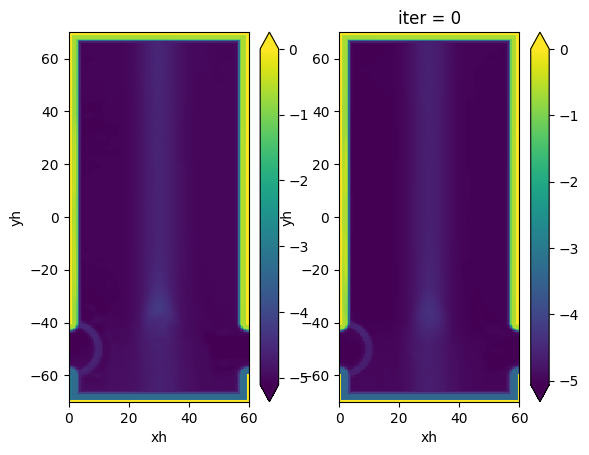

In [75]:
plt.subplot(1,2,1)
e_scaled_true.sum('zi').plot(robust=True)
plt.subplot(1,2,2)
e_scaled_model.sum('zi').plot(robust=True)

Text(0.5, 1.0, "Demeaned $-\\sum_{k=1}^{14}$ $\\eta_{k+1/2}$ $\\frac{g'_{k+1/2}}{g}$")

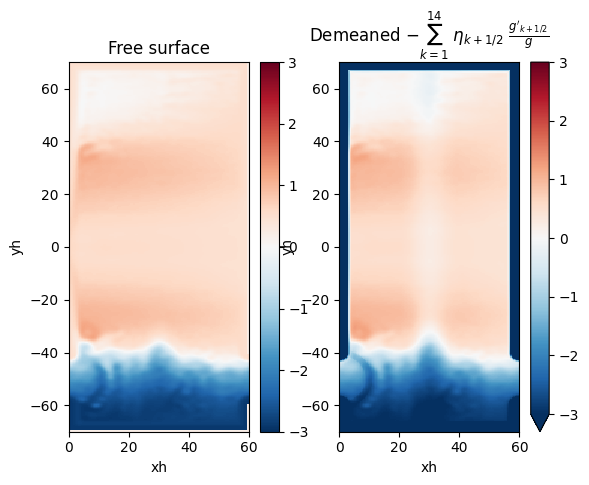

In [93]:
e_srf = e_scaled_true.isel(zi=0)
e_rest = e_scaled_true.isel(zi=slice(1,-1)).sum('zi')

e_srf = e_srf - e_srf.mean()

e_rest = e_rest + 4.5

plt.subplot(1,2,1)
e_srf.plot(vmin=-3)
plt.title('Free surface')
plt.subplot(1,2,2)
(-e_rest).plot(vmin=-3)
plt.title("Demeaned $-\sum_{k=1}^{14}$ $\eta_{k+1/2}$ $\\frac{g'_{k+1/2}}{g}$")

# Why free surface dominates loss?
Imagine that at the bottom we have cancellation of pressure gradient as follows:
$$
1 - \sum_{k=1}^{14}\frac{1}{14} = 0 
$$
Then, MSE will be of scales
$$
1, 1/196, 1/196,...
$$

# What can we do in future to equilibrate the impact of surface and subsurface?
Introduce only two variables: surface and 
$$
\sum_{k=1}^{14} g'/g \eta_{k+1/2}
$$
which on average compensate each other. On the other hand, probably, if they compensate, we can do optimization of only one variable (surface)? We leave this investigation for future.